### Graphics Models

In [10]:
# Imports
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")


In [11]:
def double_kalman(x1, x3, x1_pos, x3_pos, P1_pos, P3_pos, x_pri1, x_pri3, acel_pri1, acel_pri3):
    x_pri1.pop(0); x_pri3.pop(0)
    x_pri1.append(x1); x_pri3.append(x3)
    a1 = (x_pri1[2] - 2*x_pri1[1] + x_pri1[0]) / 0.05**2
    a3 = (x_pri3[2] - 2*x_pri3[1] + x_pri3[0]) / 0.05**2
    acel_pri1.pop(0); acel_pri3.pop(0)
    acel_pri1.append(a1); acel_pri3.append(a3)
    acel_avr1 = sum(acel_pri1) / len(acel_pri1)
    acel_avr3 = sum(acel_pri3) / len(acel_pri3)

    x1_pri = np.array([[1, 0.05], [0, 1]]) @ x1_pos + np.array([[0], [t]]) * acel_avr1
    x3_pri = np.array([[1, 0.05], [0, 1]]) @ x3_pos + np.array([[0], [t]]) * acel_avr3

    P1_pri = np.array([[1, 0.05], [0, 1]]) @ P1_pos @ np.array([[1, 0.05], [0, 1]]).T + np.array([[1e-5, 0], [0, 1e-3]])
    P3_pri = np.array([[1, 0.05], [0, 1]]) @ P3_pos @ np.array([[1, 0.05], [0, 1]]).T + np.array([[1e-5, 0], [0, 1e-3]])

    K1 = P1_pri @ np.array([[1, 0], [0, 0]]).T @ np.linalg.inv(np.array([[1, 0], [0, 0]]) @ P1_pri @ np.array([[1, 0], [0, 0]]).T + np.array([[1e-4, 0], [0, 1e-2]]))
    K3 = P3_pri @ np.array([[1, 0], [0, 0]]).T @ np.linalg.inv(np.array([[1, 0], [0, 0]]) @ P3_pri @ np.array([[1, 0], [0, 0]]).T + np.array([[1e-4, 0], [0, 1e-2]]))

    z1 = np.array([[x1], [0]])
    z3 = np.array([[x3], [0]])

    x1_pos = x1_pri + K1 @ (z1 - np.array([[1, 0], [0, 0]]) @ x1_pri)
    x3_pos = x3_pri + K3 @ (z3 - np.array([[1, 0], [0, 0]]) @ x3_pri)

    P1_pos = P1_pri - K1 @ np.array([[1, 0], [0, 0]]) @ P1_pri
    P3_pos = P3_pri - K3 @ np.array([[1, 0], [0, 0]]) @ P3_pri

    return x1_pos, x3_pos, P1_pos, P3_pos
def calcular_velocidades(df, t=0.05):
    """
    Calcula velocidades linear e angular a partir de um DataFrame com colunas x1_real e x3_real.

    Parâmetros:
    - df : pd.DataFrame – DataFrame contendo colunas 'x1_real' e 'x3_real'
    - t  : float         – intervalo de tempo entre amostras (default: 0.05s)

    Retorna:
    - df : pd.DataFrame – DataFrame original com duas novas colunas:
        - 'v_linear'  : velocidade linear estimada (dx1/dt)
        - 'v_angular' : velocidade angular estimada (dx3/dt)
    """
    x1 = np.asarray(df["x1"])
    x3 = np.asarray(df["x3"])

    v_linear = np.gradient(x1, t)
    v_angular = np.gradient(x3, t)

    df["x2"] = v_linear
    df["x4"] = v_angular

    return df

In [12]:
col = {
    "Yellow": "#F0E442",
    "Cyan": "#00FFFF",
    "Magenta": "#FF00FF",
    "Vermilion": "#D55E00",
    "Reddish Purple": "#CC79A7",
    "Sky Blue": "#56B4E9",
    "Pink": "#FFC0CB",
    "Light Blue": "#ADD8E6",
    "Light Green": "#90EE90",
    "Light Orange": "#FFA07A",
    "Light Gray": "#BEBEBE",
    "Blue": "#0072B2",
    "Bluish Green": "#009E73",
    "Orange": "#E69F00",
    "Gray": "#999999",
    "Dark Gray": "#666666",
    "Dark Blue": "#00008B",
    "Dark Red": "#8B0000",
    "Dark Green": "#006400",
    "Dark Yellow": "#9ACD32",
    "Teal": "#008080",               
    "Mustard": "#B8860B",            
    "Turquoise": "#40E0D0",          
    "Coral": "#FF7F50",              
    "Steel Blue": "#4682B4",         
    "Olive": "#808000",              
    "Brown": "#A52A2A",              
    "Lavender": "#E6E6FA",           
    "Indigo": "#4B0082",             
    "Charcoal": "#36454F"            
}

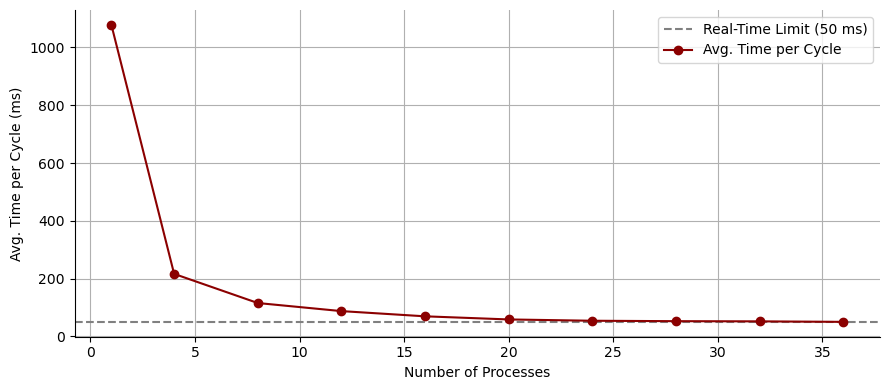

In [29]:
processos = [1, 4, 8, 12, 16, 20, 24, 28, 32, 36]
tempos_totais = [21.5668, 4.3222, 2.3046, 1.7452, 1.3842, 1.1682, 1.0777, 1.0482, 1.0356, 1.0000]
tempo_ciclo_ms = [(t * 1000) / 20 for t in tempos_totais]

# Plot
#sns.set(style="whitegrid")
plt.figure(figsize=(9, 4))
plt.axhline(50, color='gray', linestyle='--', label="Real-Time Limit (50 ms)")
plt.plot(processos, tempo_ciclo_ms, marker='o', color="#8B0000", label="Avg. Time per Cycle")

plt.xlabel("Number of Processes")
plt.ylabel("Avg. Time per Cycle (ms)")
#plt.title("Execution Time per Cycle vs. Number of Processes")
plt.legend()
plt.grid(True)
sns.despine()
plt.tight_layout()
plt.savefig("figure_pe2.pdf")
plt.show()

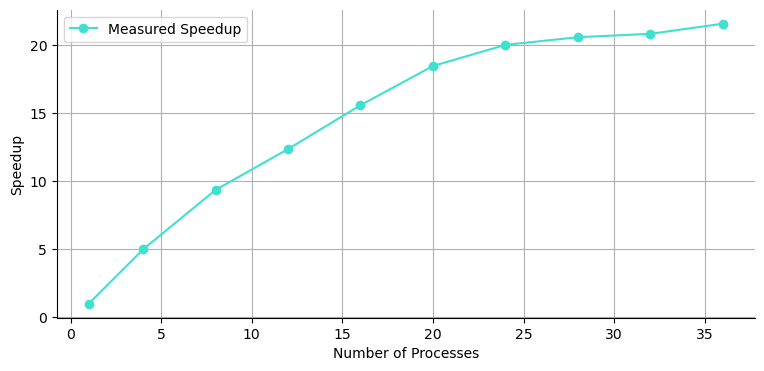

In [14]:
processos = [1, 4, 8, 12, 16, 20, 24, 28, 32, 36]
tempos_totais = [21.5668, 4.3222, 2.3046, 1.7452, 1.3842, 1.1682, 1.0777, 1.0482, 1.0356, 1.0000]
# Speedup calculation
tempo_base = tempos_totais[0]
speedup = [tempo_base / t for t in tempos_totais]

plt.figure(figsize=(9, 4))
plt.plot(processos, speedup, marker='o',color ="#40E0D0", label="Measured Speedup")
plt.xlabel("Number of Processes")
plt.ylabel("Speedup")
plt.grid(True)
plt.legend()
sns.despine()
plt.savefig('Exemple.pdf')
plt.show()

In [13]:
def calcular_velocidades(df, t=0.05):
    """
    Calcula velocidades linear e angular a partir de um DataFrame com colunas x1_real e x3_real.

    Parâmetros:
    - df : pd.DataFrame – DataFrame contendo colunas 'x1_real' e 'x3_real'
    - t  : float         – intervalo de tempo entre amostras (default: 0.05s)

    Retorna:
    - df : pd.DataFrame – DataFrame original com duas novas colunas:
        - 'v_linear'  : velocidade linear estimada (dx1/dt)
        - 'v_angular' : velocidade angular estimada (dx3/dt)
    """
    x1 = np.asarray(df["x1_real"])
    x3 = np.asarray(df["x3_real"])

    v_linear = np.gradient(x1, t)
    v_angular = np.gradient(x3, t)

    df["x2_real"] = v_linear
    df["x4_real"] = v_angular

    return df

In [14]:
def double_kalman(x1, x3, x1_pos, x3_pos, P1_pos, P3_pos, x_pri1, x_pri3, acel_pri1, acel_pri3):
    x_pri1.pop(0); x_pri3.pop(0)
    x_pri1.append(x1); x_pri3.append(x3)
    a1 = (x_pri1[2] - 2*x_pri1[1] + x_pri1[0]) / 0.05**2
    a3 = (x_pri3[2] - 2*x_pri3[1] + x_pri3[0]) / 0.05**2
    acel_pri1.pop(0); acel_pri3.pop(0)
    acel_pri1.append(a1); acel_pri3.append(a3)
    acel_avr1 = sum(acel_pri1) / len(acel_pri1)
    acel_avr3 = sum(acel_pri3) / len(acel_pri3)

    x1_pri = np.array([[1, 0.05], [0, 1]]) @ x1_pos + np.array([[0], [t]]) * acel_avr1
    x3_pri = np.array([[1, 0.05], [0, 1]]) @ x3_pos + np.array([[0], [t]]) * acel_avr3

    P1_pri = np.array([[1, 0.05], [0, 1]]) @ P1_pos @ np.array([[1, 0.05], [0, 1]]).T + np.array([[1e-5, 0], [0, 1e-3]])
    P3_pri = np.array([[1, 0.05], [0, 1]]) @ P3_pos @ np.array([[1, 0.05], [0, 1]]).T + np.array([[1e-5, 0], [0, 1e-3]])

    K1 = P1_pri @ np.array([[1, 0], [0, 0]]).T @ np.linalg.inv(np.array([[1, 0], [0, 0]]) @ P1_pri @ np.array([[1, 0], [0, 0]]).T + np.array([[1e-4, 0], [0, 1e-2]]))
    K3 = P3_pri @ np.array([[1, 0], [0, 0]]).T @ np.linalg.inv(np.array([[1, 0], [0, 0]]) @ P3_pri @ np.array([[1, 0], [0, 0]]).T + np.array([[1e-4, 0], [0, 1e-2]]))

    z1 = np.array([[x1], [0]])
    z3 = np.array([[x3], [0]])

    x1_pos = x1_pri + K1 @ (z1 - np.array([[1, 0], [0, 0]]) @ x1_pri)
    x3_pos = x3_pri + K3 @ (z3 - np.array([[1, 0], [0, 0]]) @ x3_pri)

    P1_pos = P1_pri - K1 @ np.array([[1, 0], [0, 0]]) @ P1_pri
    P3_pos = P3_pri - K3 @ np.array([[1, 0], [0, 0]]) @ P3_pri

    return x1_pos, x3_pos, P1_pos, P3_pos

In [15]:
df = pd.read_csv('Backup/Data_B50ms.csv',header=None)
df = df.T
df.columns = ["n","x1_kf","x2_kf","x3_kf","x4_kf","x1_real","x3_real","u",'INPUT','ruido',"Latency","t","k"]
df = df[["x1_real","x3_real","u"]]
df["x1_real"]  = pd.to_numeric(df["x1_real"])
df["x3_real"]  = pd.to_numeric(df["x3_real"])
df["u"]  = pd.to_numeric(df["u"])
df = calcular_velocidades(df)
t = 0.05

## FILTER VARIABLES
x1_pos = np.zeros((2,1)); x3_pos = np.zeros((2,1))
P1_pos = np.zeros((2,2)); P3_pos = np.zeros((2,2))

## MOVING AVERAGE VARIABLES
x_pri1 = [0]*3; x_pri3 = [0]*3
acel_pri1 = [0]*20; acel_pri3 = [0]*20

X1 = [] 
X2 = []
X3 = []
X4 = []

X1.insert(0, x1_pos[0, 0])
X2.insert(0, x1_pos[1, 0])
X3.insert(0, x3_pos[0, 0])
X4.insert(0, x3_pos[1, 0])

for i in range(1, len(df["x1_real"])):
    x1 = df["x1_real"][i]
    x3 = df["x3_real"][i]

    x = np.array([[x1_pos[0][0]],[x1_pos[1][0]],[x3_pos[0][0]],[x3_pos[1][0]]])
    x1_pos, x3_pos, P1_pos, P3_pos = double_kalman(x1, x3, x1_pos, x3_pos, P1_pos, P3_pos, x_pri1, x_pri3, acel_pri1, acel_pri3)
    
    X1.append(x1_pos[0][0])
    X2.append(x1_pos[1][0])
    X3.append(x3_pos[0][0])
    X4.append(x3_pos[1][0])

df_output = pd.DataFrame()
df_output["x1_real"] = df["x1_real"]
df_output["x2_real"] = df["x2_real"]
df_output["x3_real"] = df["x3_real"]
df_output["x4_real"] = df["x4_real"]
df_output["u"] = df["u"]
df_output["x1"] = X1
df_output["x2"] = X2
df_output["x3"] = X3
df_output["x4"] = X4

df_output

,x1_real,x2_real,x3_real,x4_real,u,x1,x2,x3,x4
0,0.0000,0.212,0.024544,-0.736311,106.0,0.000000,0.000000,0.000000,0.000000
1,0.0106,0.073,-0.012272,-0.429515,-33.0,0.000964,0.010600,-0.001116,-0.012272
2,0.0073,-0.083,-0.018408,-0.061359,-50.0,0.002525,0.009688,-0.004691,-0.025266
3,0.0023,-0.102,-0.018408,-0.122718,-52.0,0.002818,0.003962,-0.009305,-0.038018
4,-0.0029,-0.149,-0.030680,-0.061359,-97.0,0.000936,-0.010605,-0.018054,-0.081120
...,...,...,...,...,...,...,...,...,...
232,-0.2395,-0.200,-0.030680,-0.122718,-99.0,-0.253551,-0.421315,-0.029527,0.143071
233,-0.2494,-0.253,-0.042951,-0.122718,-154.0,-0.262609,-0.363502,-0.032173,0.083702
234,-0.2648,-0.305,-0.042951,-0.061359,-151.0,-0.273173,-0.332519,-0.035113,0.049454
235,-0.2799,-0.328,-0.049087,0.184078,-177.0,-0.285085,-0.315265,-0.040472,0.005676


In [16]:
Ad = np.array([
    [0.99881154, 0.02072451, 0.00000000, 0.00000000],
    [0.00000000, 0.90577403, 0.00018155, 0.2575382],
    [0.00000000 ,0.04240207, 0.00099713, 0.04314354],
    [0.00000000 ,-0.30688918, 0.00002273, 0.16153037]
])

Bd = np.array([
    [5.8437248e-05],
    [1.11864222e-05],
    [8.63610521e-05],
    [9.33703916e-04]
])

x_sim_4d = []

x_next = np.array([
    [df_output["x1"].iloc[1]],
    [df_output["x2"].iloc[1]],
    [df_output["x3"].iloc[1]],
    [df_output["x4"].iloc[1]]
])

for i in range(1, len(df_output)):
    u_input = df["u"].iloc[i - 1]
    x_next = Ad @ x_next + Bd * u_input
    x_sim_4d.append(x_next.flatten())


x_sim_4d = np.array(x_sim_4d)

df_res = pd.DataFrame({
    "x1_real": df_output["x1"].iloc[1:].reset_index(drop=True),
    "x2_real": df_output["x2"].iloc[1:].reset_index(drop=True),
    "x3_real": df_output["x3"].iloc[1:].reset_index(drop=True),
    "x4_real": df_output["x4"].iloc[1:].reset_index(drop=True),

    "x1_sim": x_sim_4d[:, 0],
    "x2_sim": x_sim_4d[:, 1],
    "x3_sim": x_sim_4d[:, 2],
    "x4_sim": x_sim_4d[:, 3],
})

for i in range(1, 5):
    df_res[f"res_x{i}"] = df_res[f"x{i}_real"] - df_res[f"x{i}_sim"]

for i in range(1, 5):
    rmse = np.sqrt(mean_squared_error(df_res[f"x{i}_real"], df_res[f"x{i}_sim"]))
    

plt.tight_layout()
plt.show()

for i in range(1, 5):
    print(f"RMSE x{i}: {rmse:.4f}")

<Figure size 640x480 with 0 Axes>

RMSE x1: 0.0466
RMSE x2: 0.0466
RMSE x3: 0.0466
RMSE x4: 0.0466


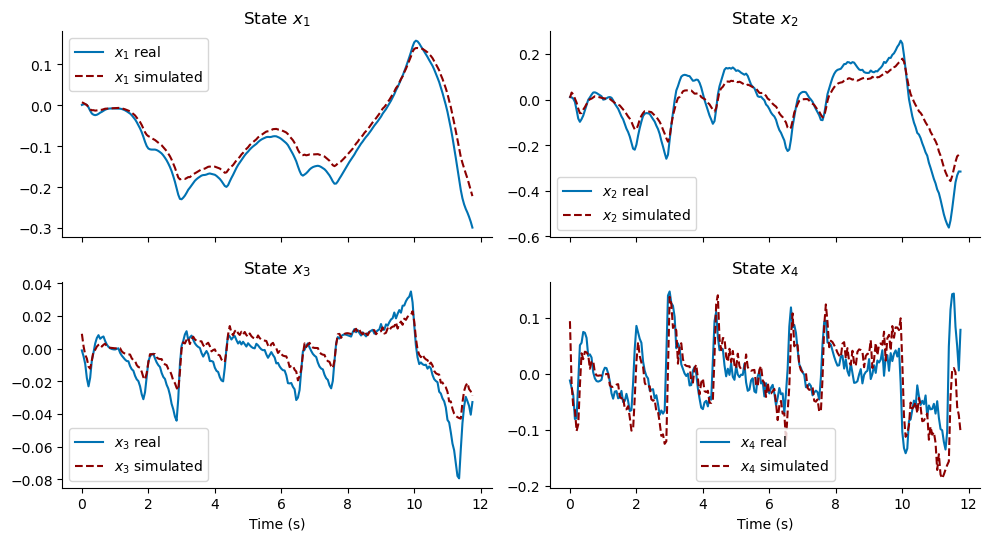

In [17]:

# Sampling period (adjust if different)
T = 0.05  # seconds

# Number of samples (use any signal length, e.g., x1_real)
n = len(df_res["x1_real"])

# Generate time vector
t = np.arange(0, n) * T  # e.g., [0.00, 0.05, 0.10, ..., (n-1)*T]


fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

# x1
axs[0, 0].plot(t,df_res["x1_real"], label="$x_1$ real", color="#0072B2")
axs[0, 0].plot(t,df_res["x1_sim"], '--', label="$x_1$ simulated", color="#8B0000")
axs[0, 0].set_title(r"State $x_1$")
axs[0, 0].legend()
sns.despine()
#axs[0, 0].grid(True)

# x2
axs[0, 1].plot(t,df_res["x2_real"], label="$x_2$ real", color="#0072B2")
axs[0, 1].plot(t,df_res["x2_sim"], '--', label="$x_2$ simulated", color="#8B0000")
axs[0, 1].set_title(r"State $x_2$")
axs[0, 1].legend()
sns.despine()
#axs[0, 1].grid(True)

# x3
axs[1, 0].plot(t,df_res["x3_real"], label="$x_3$ real", color="#0072B2")
axs[1, 0].plot(t,df_res["x3_sim"], '--', label="$x_3$ simulated", color="#8B0000")
axs[1, 0].set_title(r"State $x_3$")
axs[1, 0].set_xlabel("Time (s)")
axs[1, 0].legend()
sns.despine()
#axs[1, 0].grid(True)

# x4
axs[1, 1].plot(t,df_res["x4_real"], label="$x_4$ real", color="#0072B2")
axs[1, 1].plot(t,df_res["x4_sim"], '--', label="$x_4$ simulated", color="#8B0000")
axs[1, 1].set_title(r"State $x_4$")
axs[1, 1].set_xlabel("Time (s)")
axs[1, 1].legend()
sns.despine()
#axs[1, 1].grid(True)

#fig.suptitle("Comparison Between Real and Simulated States", fontsize=14)

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Exemple.pdf')
plt.show()


In [18]:
df = pd.read_csv('Backup/Data_A50ms.csv',header=None)
df = df.T
df.columns = ["n","x1_kf","x2_kf","x3_kf","x4_kf","x1_real","x3_real","u",'INPUT','ruido',"Latency","t","k"]
df = df[["x1_real","x3_real","u"]]
df["x1_real"]  = pd.to_numeric(df["x1_real"])
df["x3_real"]  = pd.to_numeric(df["x3_real"])
df["u"]  = pd.to_numeric(df["u"])
df = calcular_velocidades(df)
t = 0.05

## FILTER VARIABLES
x1_pos = np.zeros((2,1)); x3_pos = np.zeros((2,1))
P1_pos = np.zeros((2,2)); P3_pos = np.zeros((2,2))

## MOVING AVERAGE VARIABLES
x_pri1 = [0]*3; x_pri3 = [0]*3
acel_pri1 = [0]*20; acel_pri3 = [0]*20

X1 = [] 
X2 = []
X3 = []
X4 = []

X1.insert(0, x1_pos[0, 0])
X2.insert(0, x1_pos[1, 0])
X3.insert(0, x3_pos[0, 0])
X4.insert(0, x3_pos[1, 0])

for i in range(1, len(df["x1_real"])):
    x1 = df["x1_real"][i]
    x3 = df["x3_real"][i]

    x = np.array([[x1_pos[0][0]],[x1_pos[1][0]],[x3_pos[0][0]],[x3_pos[1][0]]])
    x1_pos, x3_pos, P1_pos, P3_pos = double_kalman(x1, x3, x1_pos, x3_pos, P1_pos, P3_pos, x_pri1, x_pri3, acel_pri1, acel_pri3)
    
    X1.append(x1_pos[0][0])
    X2.append(x1_pos[1][0])
    X3.append(x3_pos[0][0])
    X4.append(x3_pos[1][0])

df_output = pd.DataFrame()
df_output["x1_real"] = df["x1_real"]
df_output["x2_real"] = df["x2_real"]
df_output["x3_real"] = df["x3_real"]
df_output["x4_real"] = df["x4_real"]
df_output["u"] = df["u"]
df_output["x1"] = X1
df_output["x2"] = X2
df_output["x3"] = X3
df_output["x4"] = X4

df_output

,x1_real,x2_real,x3_real,x4_real,u,x1,x2,x3,x4
0,0.0000,0.212,0.024544,-0.613592,106.0,0.000000,0.000000,0.000000,0.000000
1,0.0106,0.087,-0.006136,-0.306796,-19.0,0.000964,0.010600,-0.000558,-0.006136
2,0.0087,-0.039,-0.006136,0.122718,-20.0,0.002773,0.011663,-0.001801,-0.008304
3,0.0067,-0.002,0.006136,0.122718,18.0,0.004256,0.013087,0.000032,0.012520
4,0.0085,0.037,0.006136,0.000000,19.0,0.006173,0.020570,0.002584,0.021193
...,...,...,...,...,...,...,...,...,...
1194,0.0285,-0.016,0.000000,0.000000,-8.0,0.028857,-0.013105,-0.000224,-0.001872
1195,0.0277,-0.015,0.000000,-0.061359,-7.0,0.027963,-0.013853,-0.000167,-0.001144
1196,0.0270,-0.043,-0.006136,0.000000,-36.0,0.027141,-0.014072,-0.003039,-0.020811
1197,0.0234,-0.042,0.000000,0.061359,-6.0,0.024991,-0.023524,-0.002137,-0.005338


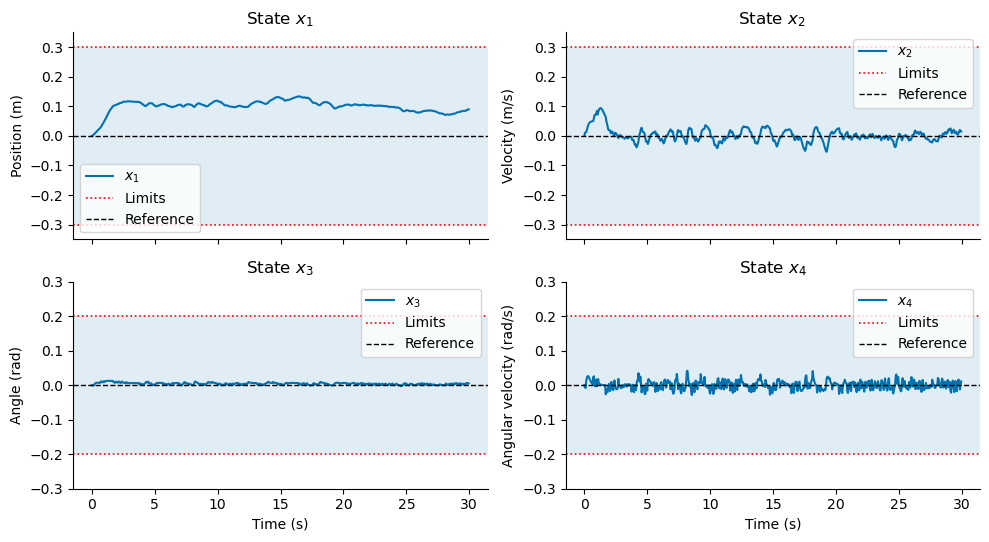

In [54]:

# Seleciona apenas os primeiros 600 pontos
N = 600
df_plot = df_output.iloc[:N]

# Gera o vetor de tempo correspondente
t = np.arange(0, N) * 0.05  # 0.05s é o seu período de amostragem

fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

# x1
axs[0, 0].plot(t, df_plot["x1"], label="$x_1$", color="#0072B2")
axs[0, 0].axhline(-0.30, color="red", linestyle=":", linewidth=1.2, label=f"Limits")
axs[0, 0].axhline(0.30, color="red", linestyle=":", linewidth=1.2)
axs[0, 0].axhline(0, color='black', linestyle='--', linewidth=1, label="Reference")
axs[0, 0].axhspan(-0.30, 0.30, facecolor="#0072B2", alpha=0.12, zorder=0)#, label="Valid range")
axs[0, 0].set_title(r"State $x_1$ ")
axs[0, 0].set_ylabel("Position (m)")
axs[0, 0].set_ylim([-0.35, 0.35])
axs[0, 0].legend()
sns.despine()

# x2
axs[0, 1].plot(t, df_plot["x2"], label="$x_2$", color="#0072B2")
axs[0, 1].axhline(-0.30, color="red", linestyle=":", linewidth=1.2, label=f"Limits")
axs[0, 1].axhline(0.30, color="red", linestyle=":", linewidth=1.2)
axs[0, 1].axhline(0, color='black', linestyle='--', linewidth=1, label="Reference")
axs[0, 1].axhspan(-0.30, 0.30, facecolor="#0072B2", alpha=0.12, zorder=0)
axs[0, 1].set_title(r"State $x_2$ ")
axs[0, 1].set_ylabel("Velocity (m/s)")
axs[0, 1].set_ylim([-0.35, 0.35])
axs[0, 1].legend()
sns.despine()

# x3
axs[1, 0].plot(t, df_plot["x3"], label="$x_3$", color="#0072B2")
axs[1, 0].axhline(-0.20, color="red", linestyle=":", linewidth=1.2, label=f"Limits")
axs[1, 0].axhline(0.20, color="red", linestyle=":", linewidth=1.2)
axs[1, 0].axhline(0, color='black', linestyle='--', linewidth=1, label="Reference")
axs[1, 0].axhspan(-0.20, 0.20, facecolor="#0072B2", alpha=0.12, zorder=0)
axs[1, 0].set_title(r"State $x_3$ ")
axs[1, 0].set_xlabel("Time (s)")
axs[1, 0].set_ylabel("Angle (rad)")
axs[1, 0].set_ylim([-0.3, 0.3])
axs[1, 0].legend()
sns.despine()

# x4
axs[1, 1].plot(t, df_plot["x4"], label="$x_4$", color="#0072B2")
axs[1, 1].axhline(-0.20, color="red", linestyle=":", linewidth=1.2, label=f"Limits")
axs[1, 1].axhline(0.20, color="red", linestyle=":", linewidth=1.2)
axs[1, 1].axhline(0, color='black', linestyle='--', linewidth=1, label="Reference")
axs[1, 1].axhspan(-0.20, 0.20, facecolor="#0072B2", alpha=0.12, zorder=0)
axs[1, 1].set_title(r"State $x_4$")
axs[1, 1].set_xlabel("Time (s)")
axs[1, 1].set_ylabel("Angular velocity (rad/s)")
axs[1, 1].set_ylim([-0.3, 0.3])
axs[1, 1].legend()
sns.despine()

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Exemple.pdf')
plt.show()


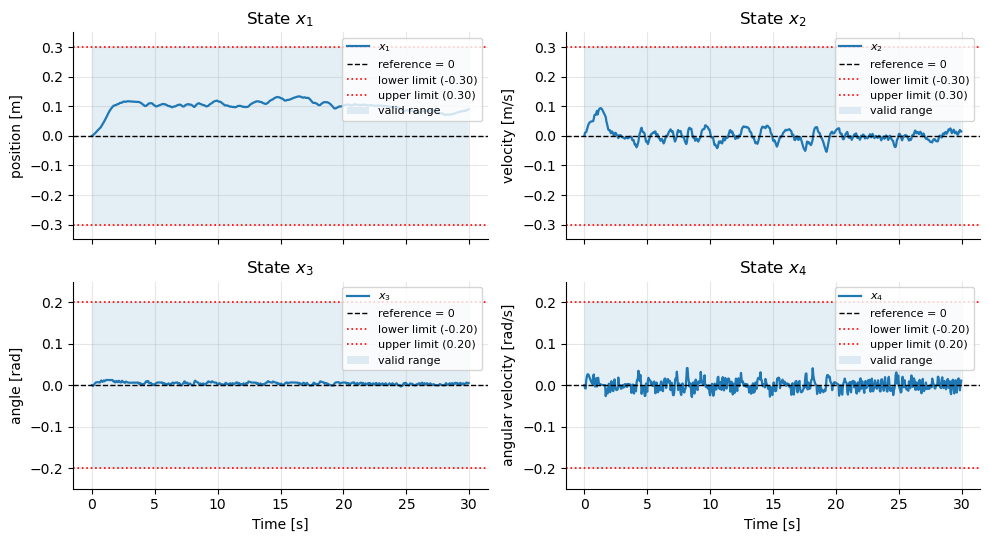

In [21]:
# --- Parameters for limits (with margin for visualization) ---
lim_x1 = (-0.30, 0.30)      # cart position [m]
lim_x2 = (-0.30, 0.30)      # cart velocity [m/s]
lim_x3 = (-0.20, 0.20)      # pendulum angle [rad]
lim_x4 = (-0.20, 0.20)      # angular velocity [rad/s]

# margins to make plots a bit looser
margin = 0.05
ylims = {
    "x1": (lim_x1[0] - margin, lim_x1[1] + margin),
    "x2": (lim_x2[0] - margin, lim_x2[1] + margin),
    "x3": (lim_x3[0] - 0.05,  lim_x3[1] + 0.05),
    "x4": (lim_x4[0] - 0.05,  lim_x4[1] + 0.05),
}

# --- Select data and time vector ---
N = 600
df_plot = df_output.iloc[:N]
t = np.arange(0, N) * 0.05  # T = 0.05 s

# --- Plot ---
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

def plot_state(ax, t, y, name, limits, ylim, ylabel=None):
    ax.plot(t, y, label=fr"$ {name} $", linewidth=1.6)
    ax.axhline(0, color="black", linestyle="--", linewidth=1, label="reference = 0")
    ax.axhline(limits[0], color="red", linestyle=":", linewidth=1.2, label=f"lower limit ({limits[0]:.2f})")
    ax.axhline(limits[1], color="red", linestyle=":", linewidth=1.2, label=f"upper limit ({limits[1]:.2f})")
    ax.fill_between(t, limits[0], limits[1], alpha=0.12, label="valid range")
    ax.set_title(rf"State $ {name} $")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

# x1
plot_state(axs[0, 0], t, df_plot["x1"], "x_1", lim_x1, ylims["x1"], ylabel="position [m]")
# x2
plot_state(axs[0, 1], t, df_plot["x2"], "x_2", lim_x2, ylims["x2"], ylabel="velocity [m/s]")
# x3
plot_state(axs[1, 0], t, df_plot["x3"], "x_3", lim_x3, ylims["x3"], ylabel="angle [rad]")
axs[1, 0].set_xlabel("Time [s]")
# x4
plot_state(axs[1, 1], t, df_plot["x4"], "x_4", lim_x4, ylims["x4"], ylabel="angular velocity [rad/s]")
axs[1, 1].set_xlabel("Time [s]")

fig.tight_layout(rect=[0, 0.03, 1, 0.95])

try:
    import seaborn as sns
    sns.despine()
except Exception:
    pass

plt.savefig("Example.pdf")
plt.show()


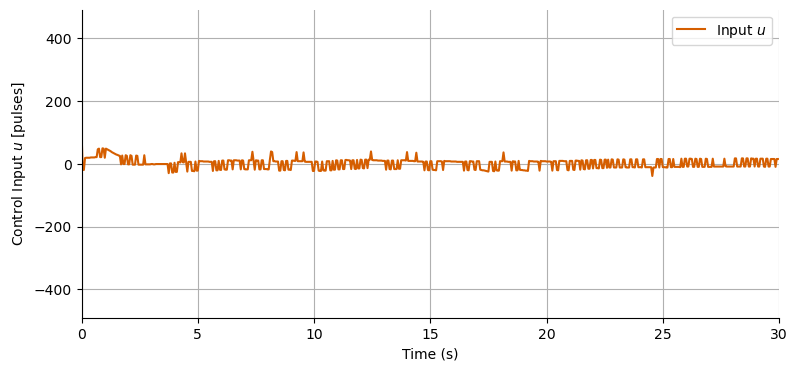

In [ ]:
# Seleção dos dados
N = 600
df_plot = df_output.iloc[:N]
t = np.arange(0, N) * 0.05  # vetor de tempo

plt.figure(figsize=(9, 4))
plt.plot(t, df_plot["u"], color="#D55E00", label="Input $u$")

# Limites dos eixos (ajuste conforme necessário)
plt.xlim(0, 30)           # de 0 a 30 segundos
plt.ylim(-490, 490)     # ajuste para o seu range de pulso

# Rótulos dos eixos (preencha se quiser)
plt.ylabel("Control Input $u$ [pulses]")
plt.xlabel("Time (s)")

# Grade e limpeza de bordas
plt.grid(True)
sns.despine()

# Salvar a figura se quiser
plt.savefig('Input_U.pdf')

plt.legend()
plt.show()



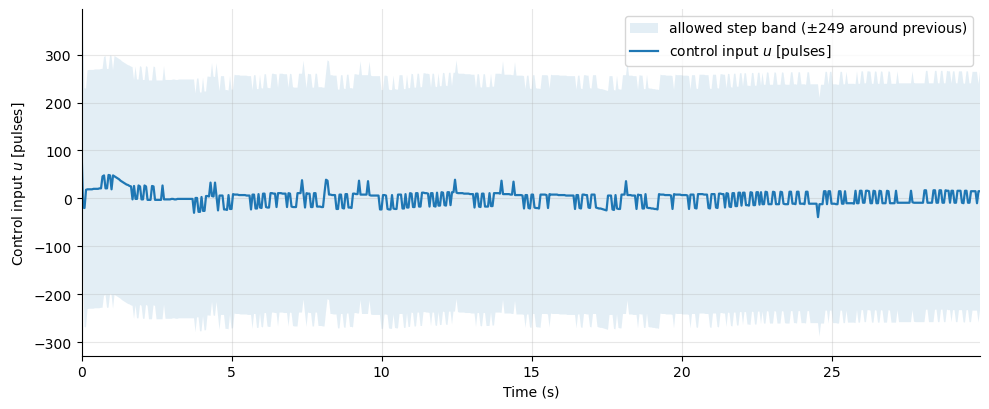

In [49]:
DT = 0.05
STEP_LIMIT = 249    # limite de variação por amostra (±)

# --- seleção dos dados ---
N = 600
df_plot = df_output.iloc[:N].copy()
t = np.arange(0, N) * DT
u = df_plot["u"].to_numpy()

# --- diferenças por amostra (Δu_k = u_k - u_{k-1}) ---
du = np.diff(u, prepend=u[0])

# violações: |Δu| > 249
viol = np.abs(du) > STEP_LIMIT

# --- envelope dinâmico permitido em cada amostra ---
# limite inferior/superior em k é u_{k-1} ± 249
u_prev = np.roll(u, 1)
u_prev[0] = u[0]            # para k=0, não há restrição histórica; mantenho igual só pra desenhar
lower = u_prev - STEP_LIMIT
upper = u_prev + STEP_LIMIT

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4.2))

# faixa válida (dinâmica): entre u_{k-1}-249 e u_{k-1}+249
plt.fill_between(t, lower, upper, alpha=0.12, label="allowed step band (±249 around previous)")

# sinal u
plt.plot(t, u, linewidth=1.6, label="control input $u$ [pulses]")

# marcações de violação
if viol.any():
    plt.scatter(t[viol], u[viol], s=22, color="red", zorder=3, label="step-limit violation (|Δu|>249)")

plt.xlabel("Time (s)")
plt.ylabel("Control input $u$ [pulses]")

# limites dos eixos (auto com margem)
margin = 40
plt.xlim(0, t[-1])
plt.ylim(min(lower.min(), u.min()) - margin, max(upper.max(), u.max()) + margin)

plt.grid(True, alpha=0.3)
try:
    import seaborn as sns
    sns.despine()
except Exception:
    pass

plt.legend(loc="best")
plt.tight_layout()
plt.savefig("Input_U_step_limit.pdf")
plt.show()


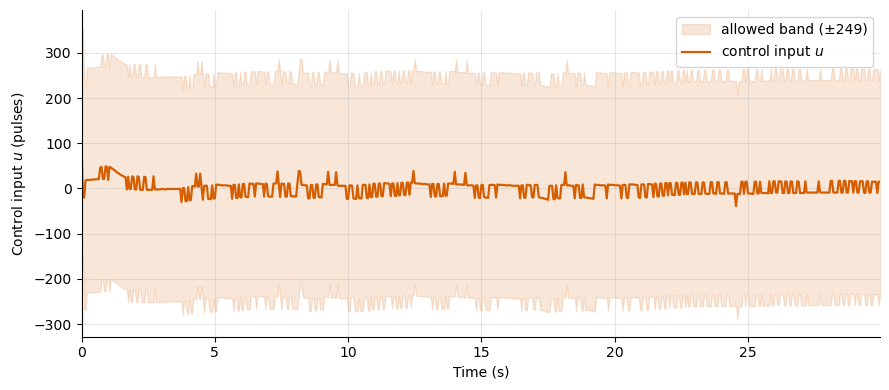

In [ ]:
import matplotlib.pyplot as plt

DT = 0.05
STEP_LIMIT = 249    # limite de variação por amostra (±)

# --- seleção dos dados ---
N = 600
df_plot = df_output.iloc[:N].copy()
t = np.arange(0, N) * DT
u = df_plot["u"].to_numpy()

# --- diferenças por amostra (Δu_k = u_k - u_{k-1}) ---
du = np.diff(u, prepend=u[0])
viol = np.abs(du) > STEP_LIMIT

# --- envelope dinâmico permitido ---
u_prev = np.roll(u, 1)
u_prev[0] = u[0]
lower = u_prev - STEP_LIMIT
upper = u_prev + STEP_LIMIT

# --- plot ---
plt.figure(figsize=(9, 4))

# faixa válida (sombreada na mesma cor, mas transparente)
plt.fill_between(t, lower, upper, color="#D55E00", alpha=0.15, label="allowed band (±249)")

# sinal u
plt.plot(t, u, color="#D55E00", linewidth=1.6, label="control input $u$")

# violações
if viol.any():
    plt.scatter(t[viol], u[viol], s=22, color="red", zorder=3, label="violation (|Δu|>249)")

# rótulos e estilo
plt.xlabel("Time (s)")
plt.ylabel("Control input $u$ (pulses)")
plt.xlim(0, t[-1])
plt.ylim(min(lower.min(), u.min()) - 40, max(upper.max(), u.max()) + 40)

plt.grid(True, alpha=0.3)
try:
    import seaborn as sns
    sns.despine()
except Exception:
    pass

plt.legend(loc="best")
plt.tight_layout()
plt.savefig("Input_U_colored.pdf")
plt.show()
